<a href="https://colab.research.google.com/github/saitejaswinigarlapati/Alzheimers-MRI-Image-Classification/blob/main/Deep_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from collections import Counter
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm
import os

import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
from PIL import Image
from torchvision import transforms
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE



In [ ]:
save_folder = "/content/drive/MyDrive/Colab Notebooks/Alzheimer's MRI 4 Class Classification"

# Create folder if it doesn't exist
import os
os.makedirs(save_folder, exist_ok=True)

In [ ]:
path = "/content/drive/MyDrive/Alzheimer_MRI_4_classes_dataset"


In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [ ]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


PyTorch version: 2.10.0+cu128
CUDA available: True
Device count: 1
GPU name: Tesla T4


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import Counter
from torch.cuda.amp import GradScaler, autocast
from tqdm import tqdm
import os

In [ ]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


In [ ]:
full_dataset = datasets.ImageFolder(path)
print("Total samples:", len(full_dataset))
print("Number of classes:", len(full_dataset.classes))
print("Class names:", full_dataset.classes)

Total samples: 6400
Number of classes: 4
Class names: ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']


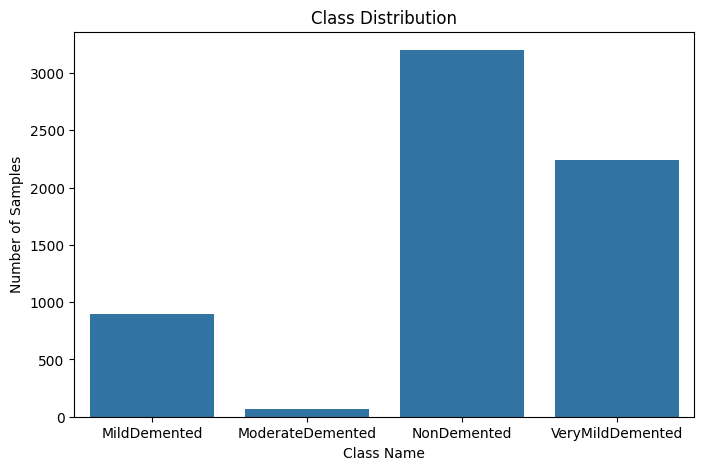

In [ ]:
from collections import Counter

# full_dataset.targets contains labels for ImageFolder datasets
class_counts = Counter(full_dataset.targets)

# Sort counts by class index so they match class names
class_counts = dict(sorted(class_counts.items()))

plt.figure(figsize=(8,5))
sns.barplot(
    x=full_dataset.classes,
    y=list(class_counts.values())
)
plt.title("Class Distribution")
plt.xlabel("Class Name")
plt.ylabel("Number of Samples")
plt.show()


In [ ]:
import torchvision.transforms as transforms

to_tensor = transforms.ToTensor()

In [ ]:
def show_random_images(dataset, num=8):
    plt.figure(figsize=(15,6))

    for i in range(num):
        idx = random.randint(0, len(dataset)-1)
        img, label = dataset[idx]

        img = to_tensor(img)   # convert PIL → tensor

        img_show = img.permute(1,2,0).numpy()
        img_show = img_show * 0.5 + 0.5

        plt.subplot(2,4,i+1)
        plt.imshow(img_show)
        plt.title(dataset.classes[label])
        plt.axis("off")

    plt.show()

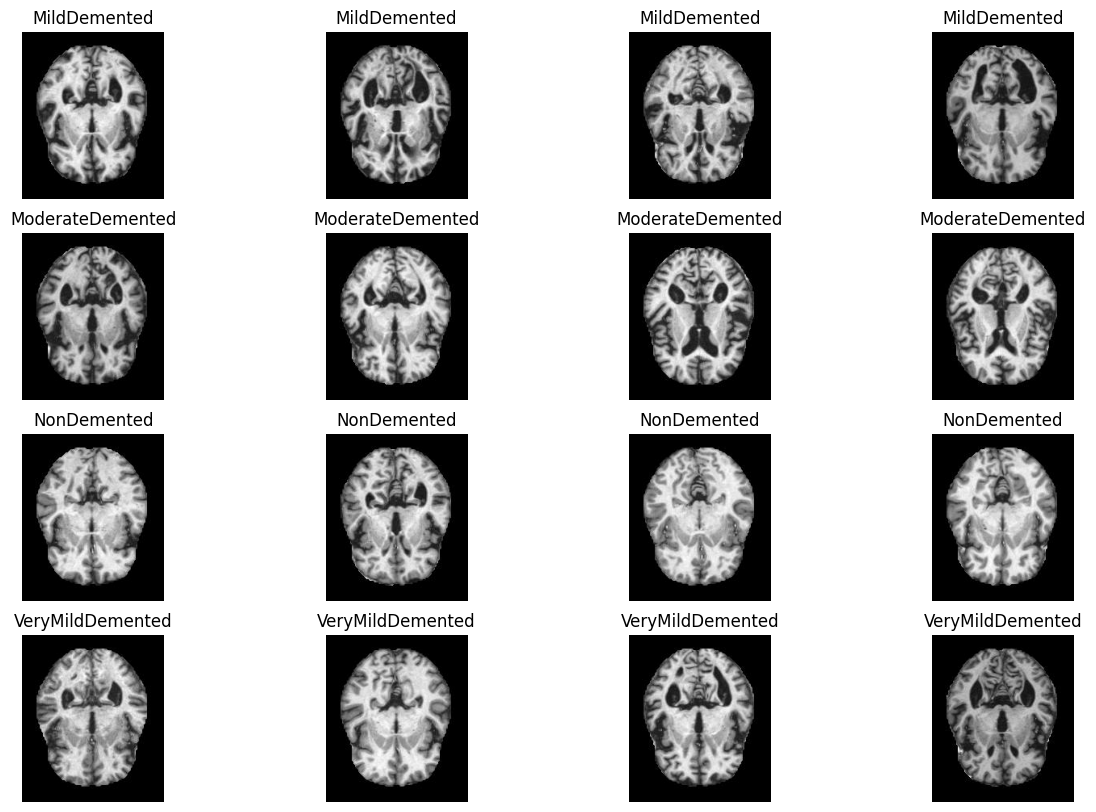

In [ ]:
def show_per_class(dataset, n=4):
    plt.figure(figsize=(15,10))
    class_to_idx = dataset.class_to_idx

    for cls_idx, cls in enumerate(dataset.classes):
        count = 0
        for img_path, label in dataset.samples:
            if label == cls_idx:
                img = Image.open(img_path).convert("L")
                plt.subplot(len(dataset.classes), n, cls_idx*n + count + 1)
                plt.imshow(img, cmap="gray")
                plt.title(cls)
                plt.axis("off")
                count += 1
                if count == n: break

    plt.show()

show_per_class(full_dataset)


In [ ]:
def visualize_augmentation(dataset):
    plt.figure(figsize=(15,6))

    idx = random.randint(0, len(dataset)-1)

    # get image path
    orig_idx = dataset.indices[idx]
    orig_path, label = dataset.dataset.samples[orig_idx]

    original_img = Image.open(orig_path).convert("L")

    # augmented image
    aug_img, _ = dataset[idx]
    aug_img = aug_img.permute(1,2,0).numpy()
    aug_img = aug_img * 0.5 + 0.5

    # show original
    plt.subplot(1,2,1)
    plt.imshow(original_img, cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # show augmented
    plt.subplot(1,2,2)
    plt.imshow(aug_img, cmap="gray")
    plt.title("Augmented")
    plt.axis("off")

    plt.show()

In [ ]:
labels = [label for _, label in full_dataset.samples]
class_counts = Counter(labels)
for class_idx, count in class_counts.items():
    print(full_dataset.classes[class_idx], ":", count)

MildDemented : 896
ModerateDemented : 64
NonDemented : 3200
VeryMildDemented : 2240


In [ ]:
torch.manual_seed(42)
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size



In [ ]:
train_indices, val_indices, test_indices = torch.utils.data.random_split(
    range(len(full_dataset)),
    [train_size, val_size, test_size]
)
train_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(path, transform=train_transform),
    train_indices.indices
)

val_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(path, transform=val_test_transform),
    val_indices.indices
)

test_dataset = torch.utils.data.Subset(
    datasets.ImageFolder(path, transform=val_test_transform),
    test_indices.indices
)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True, num_workers=2)

In [ ]:
print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 4480
Validation size: 960
Test size: 960


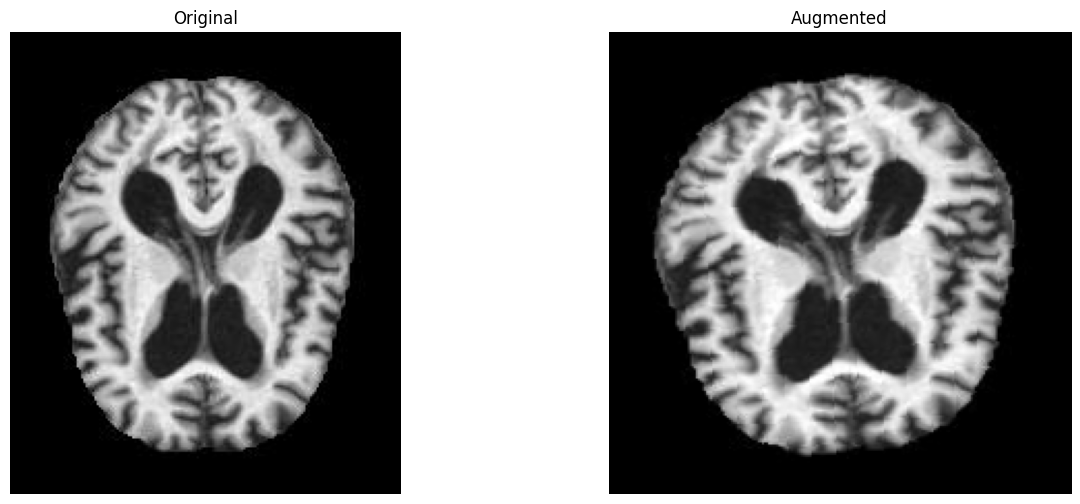

In [ ]:
visualize_augmentation(train_dataset)

In [ ]:
num_classes = len(full_dataset.classes)
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)

In [ ]:
# -----------------------------
# 1️⃣ Freeze all layers first
# -----------------------------
for param in model.parameters():
    param.requires_grad = False

# -----------------------------
# 2️⃣ Unfreeze last convolutional blocks
# -----------------------------
# MobileNetV2 features are indexed 0-18. Unfreeze last 6 blocks (13-18)
for param in model.features[13:].parameters():
    param.requires_grad = True

# -----------------------------
# 3️⃣ Define classifier with dropout
# -----------------------------
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.last_channel, 256),  # last_channel is 1280 for MobileNetV2
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)          # num_classes = 4 for your dataset
)

# -----------------------------
# 4️⃣ Move model to device
# -----------------------------
model = model.to(device)

# Optional: check which parameters are trainable
trainable_params = [name for name, p in model.named_parameters() if p.requires_grad]
print("Trainable layers:")
for name in trainable_params:
    print(name)

Trainable layers:
features.13.conv.0.0.weight
features.13.conv.0.1.weight
features.13.conv.0.1.bias
features.13.conv.1.0.weight
features.13.conv.1.1.weight
features.13.conv.1.1.bias
features.13.conv.2.weight
features.13.conv.3.weight
features.13.conv.3.bias
features.14.conv.0.0.weight
features.14.conv.0.1.weight
features.14.conv.0.1.bias
features.14.conv.1.0.weight
features.14.conv.1.1.weight
features.14.conv.1.1.bias
features.14.conv.2.weight
features.14.conv.3.weight
features.14.conv.3.bias
features.15.conv.0.0.weight
features.15.conv.0.1.weight
features.15.conv.0.1.bias
features.15.conv.1.0.weight
features.15.conv.1.1.weight
features.15.conv.1.1.bias
features.15.conv.2.weight
features.15.conv.3.weight
features.15.conv.3.bias
features.16.conv.0.0.weight
features.16.conv.0.1.weight
features.16.conv.0.1.bias
features.16.conv.1.0.weight
features.16.conv.1.1.weight
features.16.conv.1.1.bias
features.16.conv.2.weight
features.16.conv.3.weight
features.16.conv.3.bias
features.17.conv.0.0.w

In [ ]:
total = sum(class_counts.values())
weights = [total/class_counts[i] for i in range(len(class_counts))]
weights = torch.tensor(weights).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

In [ ]:
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

In [ ]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

In [ ]:
epochs = 20
scaler = GradScaler()
best_val_acc = 0
patience = 5  # stop if no improvement for 5 consecutive epochs
counter = 0   # counter for early stopping

for epoch in range(epochs):
    model.train()
    train_loss, train_correct, total_train = 0, 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        total_train += labels.size(0)

    # Validation
    model.eval()
    val_loss, val_correct, total_val = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            total_val += labels.size(0)

    # Calculate metrics
    train_loss /= total_train
    val_loss /= total_val
    train_acc = 100 * train_correct / total_train
    val_acc   = 100 * val_correct / total_val

    # Record history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    scheduler.step(val_acc)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_mobilenetv2_alzheimer.pth")
        print(f"*** Saved Best Model with Val Acc: {best_val_acc:.2f}% ***")
        counter = 0  # reset counter if improvement
    else:
        counter += 1
        print(f"No improvement in Val Acc for {counter} epoch(s).")
        if counter >= patience:
            print(f"Early stopping triggered after {patience} epochs without improvement.")
            break

/tmp/ipykernel_16182/1817137624.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/20:   0%|          | 0/140 [00:00<?, ?it/s]/tmp/ipykernel_16182/1817137624.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/20: 100%|██████████| 140/140 [01:02<00:00,  2.22it/s]


Epoch 1/20 | Train Loss: 1.2088 | Train Acc: 49.29% | Val Loss: 1.0856 | Val Acc: 50.94%
*** Saved Best Model with Val Acc: 50.94% ***


Epoch 2/20: 100%|██████████| 140/140 [00:35<00:00,  3.98it/s]


Epoch 2/20 | Train Loss: 0.9678 | Train Acc: 53.82% | Val Loss: 0.8052 | Val Acc: 58.75%
*** Saved Best Model with Val Acc: 58.75% ***


Epoch 3/20: 100%|██████████| 140/140 [00:30<00:00,  4.52it/s]


...

Epoch 18/20 | Train Loss: 0.2702 | Train Acc: 86.21% | Val Loss: 0.3017 | Val Acc: 83.02%
No improvement in Val Acc for 1 epoch(s).


Epoch 19/20: 100%|██████████| 140/140 [00:31<00:00,  4.40it/s]


Epoch 19/20 | Train Loss: 0.2977 | Train Acc: 85.85% | Val Loss: 0.2603 | Val Acc: 85.83%
*** Saved Best Model with Val Acc: 85.83% ***


Epoch 20/20: 100%|██████████| 140/140 [00:31<00:00,  4.47it/s]


Epoch 20/20 | Train Loss: 0.2796 | Train Acc: 86.54% | Val Loss: 0.2688 | Val Acc: 86.35%
*** Saved Best Model with Val Acc: 86.35% ***


In [ ]:
import json
with open(os.path.join(save_folder, "training_history.json"), "w") as f:
    json.dump(history, f)
print(f"✅ Training history saved in {save_folder}")

✅ Training history saved in /content/drive/MyDrive/Colab Notebooks/Alzheimer's MRI 4 Class Classification


In [ ]:
preprocess = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # match training
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [ ]:
import torch
import os
import json
from torchvision import transforms

# Example: your transforms (replace with your actual preprocess)
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# -------------------------
# Path from your provided code
save_folder = save_folder  # use the same variable you already have
os.makedirs(save_folder, exist_ok=True)

# -------------------------
# 1. Save only the model's state_dict
# -------------------------
torch.save(model.state_dict(), os.path.join(save_folder, "best_mobilenetv2_alzheimer.pth"))

# -------------------------
# 2. Save preprocessing as JSON
# -------------------------
def transforms_to_json(transform):
    """Convert torchvision transforms.Compose to a JSON-serializable dict."""
    transform_list = []
    for t in transform.transforms:
        t_name = t.__class__.__name__
        if t_name == "Resize":
            transform_list.append({"name": t_name, "size": t.size})
        elif t_name == "ToTensor":
            transform_list.append({"name": t_name})
        elif t_name == "Normalize":
            transform_list.append({"name": t_name, "mean": t.mean, "std": t.std})
        else:
            raise ValueError(f"Transform {t_name} not supported for JSON saving")
    return transform_list

preprocess_json = transforms_to_json(preprocess)
with open(os.path.join(save_folder, "preprocessing.json"), "w") as f:
    json.dump(preprocess_json, f, indent=4)

print(f"✅ Model state_dict saved as best_mobilenetv2_alzheimer.pth in {save_folder}")
print(f"✅ Preprocessing saved as preprocess.json in {save_folder}")

✅ Model state_dict saved as best_mobilenetv2_alzheimer.pth in /content/drive/MyDrive/Colab Notebooks/Alzheimer's MRI 4 Class Classification
✅ Preprocessing saved as preprocess.json in /content/drive/MyDrive/Colab Notebooks/Alzheimer's MRI 4 Class Classification


In [ ]:
# Validation
model.eval()
val_loss, val_correct, total_val = 0, 0, 0
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        val_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        val_correct += (preds == labels).sum().item()
        total_val += labels.size(0)

val_loss /= total_val
val_acc   = 100 * val_correct / total_val
print(f"Validation Loss: {val_loss:.4f} | Validation Acc: {val_acc:.2f}%")

Validation Loss: 0.2688 | Validation Acc: 86.35%
